In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau

import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals_validation.batch'
do_save = False

In [2]:
def _loadISA(session):

    has_isa = False
    try:
        R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval')
        has_isa = True
    except FileNotFoundError:
        R = fma.regions.regions(session,events='stimtest')
    #threshold = threshold[int(R.rat)] # extract thresholds from dict

    fr = R.firingRate(regs='nr',window=0.05,step=5,smooth=70,norm=True)
    isa = R.eventIntervals('slownr') if has_isa else np.empty((0,2))

    return fr, isa, R.basename, int(R.rat)

In [3]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][0]
print(session)
fr, isa, basename, rat = _loadISA(session)

/mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml


(500.0, 5500.0)

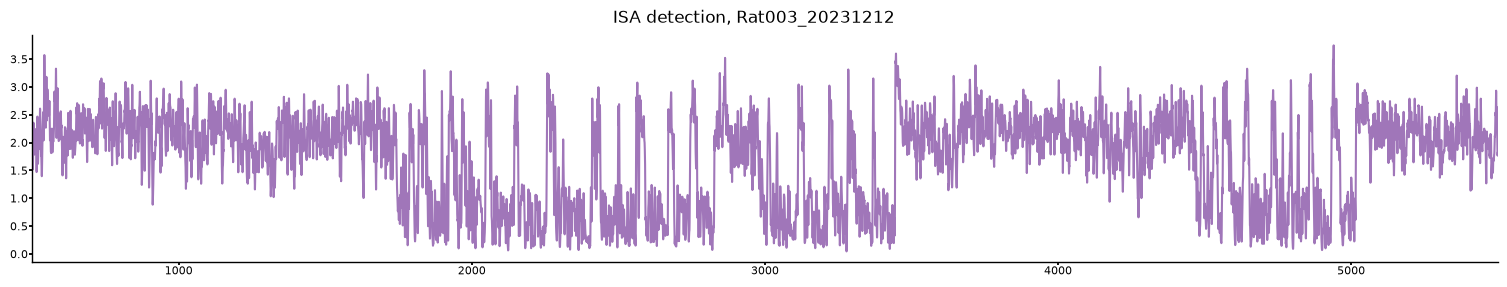

In [8]:
start = 500
stop = start + 5000
fig, ax = fma.plotting.makeFigure(f'ISA detection, {basename}',size=(38,7))

fma.plotting.plotXY(fr,start,stop,color=isau.paperColors('nr'))
#fma.plotting.plotIntervals(isr_dict[r],ax=ax[i])
#fma.plotting.plotIntervals(isr_excl_dict[r],color='r',ax=ax[i])
ax[0].set_xlim([start,stop])

run batch

In [3]:
fr, isa, basename, rat = fma.data.runBatch(batch_file,_loadISA,parallel=True)
rat = np.array(rat)


Starting Batch, 2026-08-31 11:45:54.736105 

Error in session /mnt/hubel-data-149/Photon_Rat014/Rat014_2026-07-15_13-31-42/Rat014_2026-07-15_13-31-42.xml (58)
index 0 is out of bounds for axis 0 with size 0
Traceback:
Batch completed with 1 errors, 2026-08-31 11:46:43.908744


In [6]:
# hard code parameters
window = {'Rat003_20231212': 2000, 'Rat003_20231213': 1200, 'Rat003_20231214': 9500, 'Rat003_20231215': 11500, 'Rat003_20231218': 3700, 'Rat003_20231219': 1500, 'Rat003_20231221': 3800, 'Rat003_20231222': 2700,
          'Rat003_20231223': 4000, 'Rat003_20231224': 1700, 'Rat003_20231226': 4500, 'Rat003_20231227': 4700, 'Rat003_20231228': 4000, 'Rat003_20231229': 4000,

          'Rat004_20240226': 4000, 'Rat004_20240227': 2000, 'Rat004_20240228': 2000, 'Rat004_20240303': 11000, 'Rat004_20240305': 6000, 'Rat004_20240306': 21000, 'Rat004_20240308': 2000, 'Rat004_20240309': 2500,
          'Rat004_20240310': 6000, 'Rat004_20240311': 21000, 'Rat004_20240313': 3000, 'Rat004_20240314': 2500, 'Rat004_20240315': 1000, 'Rat004_20240316': 1000, 'Rat004_20240317': 3000, 'Rat004_20240318': 2500,
          'Rat004_20240319': 3000,

          'Rat002_20230807': 3000, 'Rat002_20230808': 1000, 'Rat002_20230810': 4000, 'Rat002_20230815': 7000, 'Rat002_20230816': 3000, 'Rat002_20230817': 4000, 'Rat002_20230818': 6000, 'Rat002_20230819': 11000,
          'Rat002_20230820': 4000, 'Rat002_20230821': 4000, 'Rat002_20230822': 6000, 'Rat002_20230823': 11000,

          'Rat011_2025-12-09': 4000, 'Rat011_2025-12-10': 7000, 'Rat011_2025-12-11': 7000, 'Rat011_2025-12-12': 2500, 'Rat011_2025-12-15': 4000,'Rat011_2025-12-16': 7000, 'Rat011_2025-12-17': 7000,

          'Rat012_2025-12-05': 2000, 'Rat012_2025-12-08': 4000, 'Rat012_2025-12-09': 9000, 'Rat012_2025-12-10': 7500, 'Rat012_2025-12-12': 2500, 'Rat012_2025-12-15': 4500, 'Rat012_2025-12-16': 9000,
          'Rat012_2025-12-17': 7000,

          'Rat014_2026-07-15_13-31-42': 800}

'Rat014_2026-07-15_13-31-42': 0, 

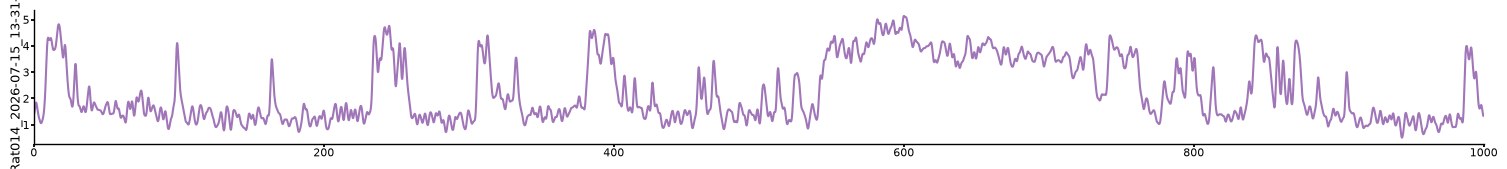

In [21]:
# choose windows
sessions = np.arange(4) + 4 * 11
sessions = [58]
start =        np.array([000,7000,2500,4500])
stop = start + np.array([1000,1000,1000,1000]) * 1
fig, ax = fma.plotting.makeFigure(n=(len(sessions),1),size=(38,4*len(sessions)))

for i, s in enumerate(sessions):
    print(f"'{basename[s]}': {start[i]}, ",end='')
    fma.plotting.plotXY(fr[s],start[i],stop[i],color=isau.paperColors('nr'),ax=ax[i])
    fma.plotting.plotIntervals(isa[s],ax=ax[i])
    ax[i].set(xlim=[start[i],stop[i]],ylabel=basename[s])

In [8]:
def score(fr,start,stop):
    fr = fma.general.restrict(fr,[start,stop])
    perc = np.percentile(fr[:,1],[5,50,95])
    sc = (perc[1]-perc[0]) / (perc[2] - perc[0])
    return sc, perc

TO DO: DIVIDE probe in 2 halves, replot FR

0.3847090697199835


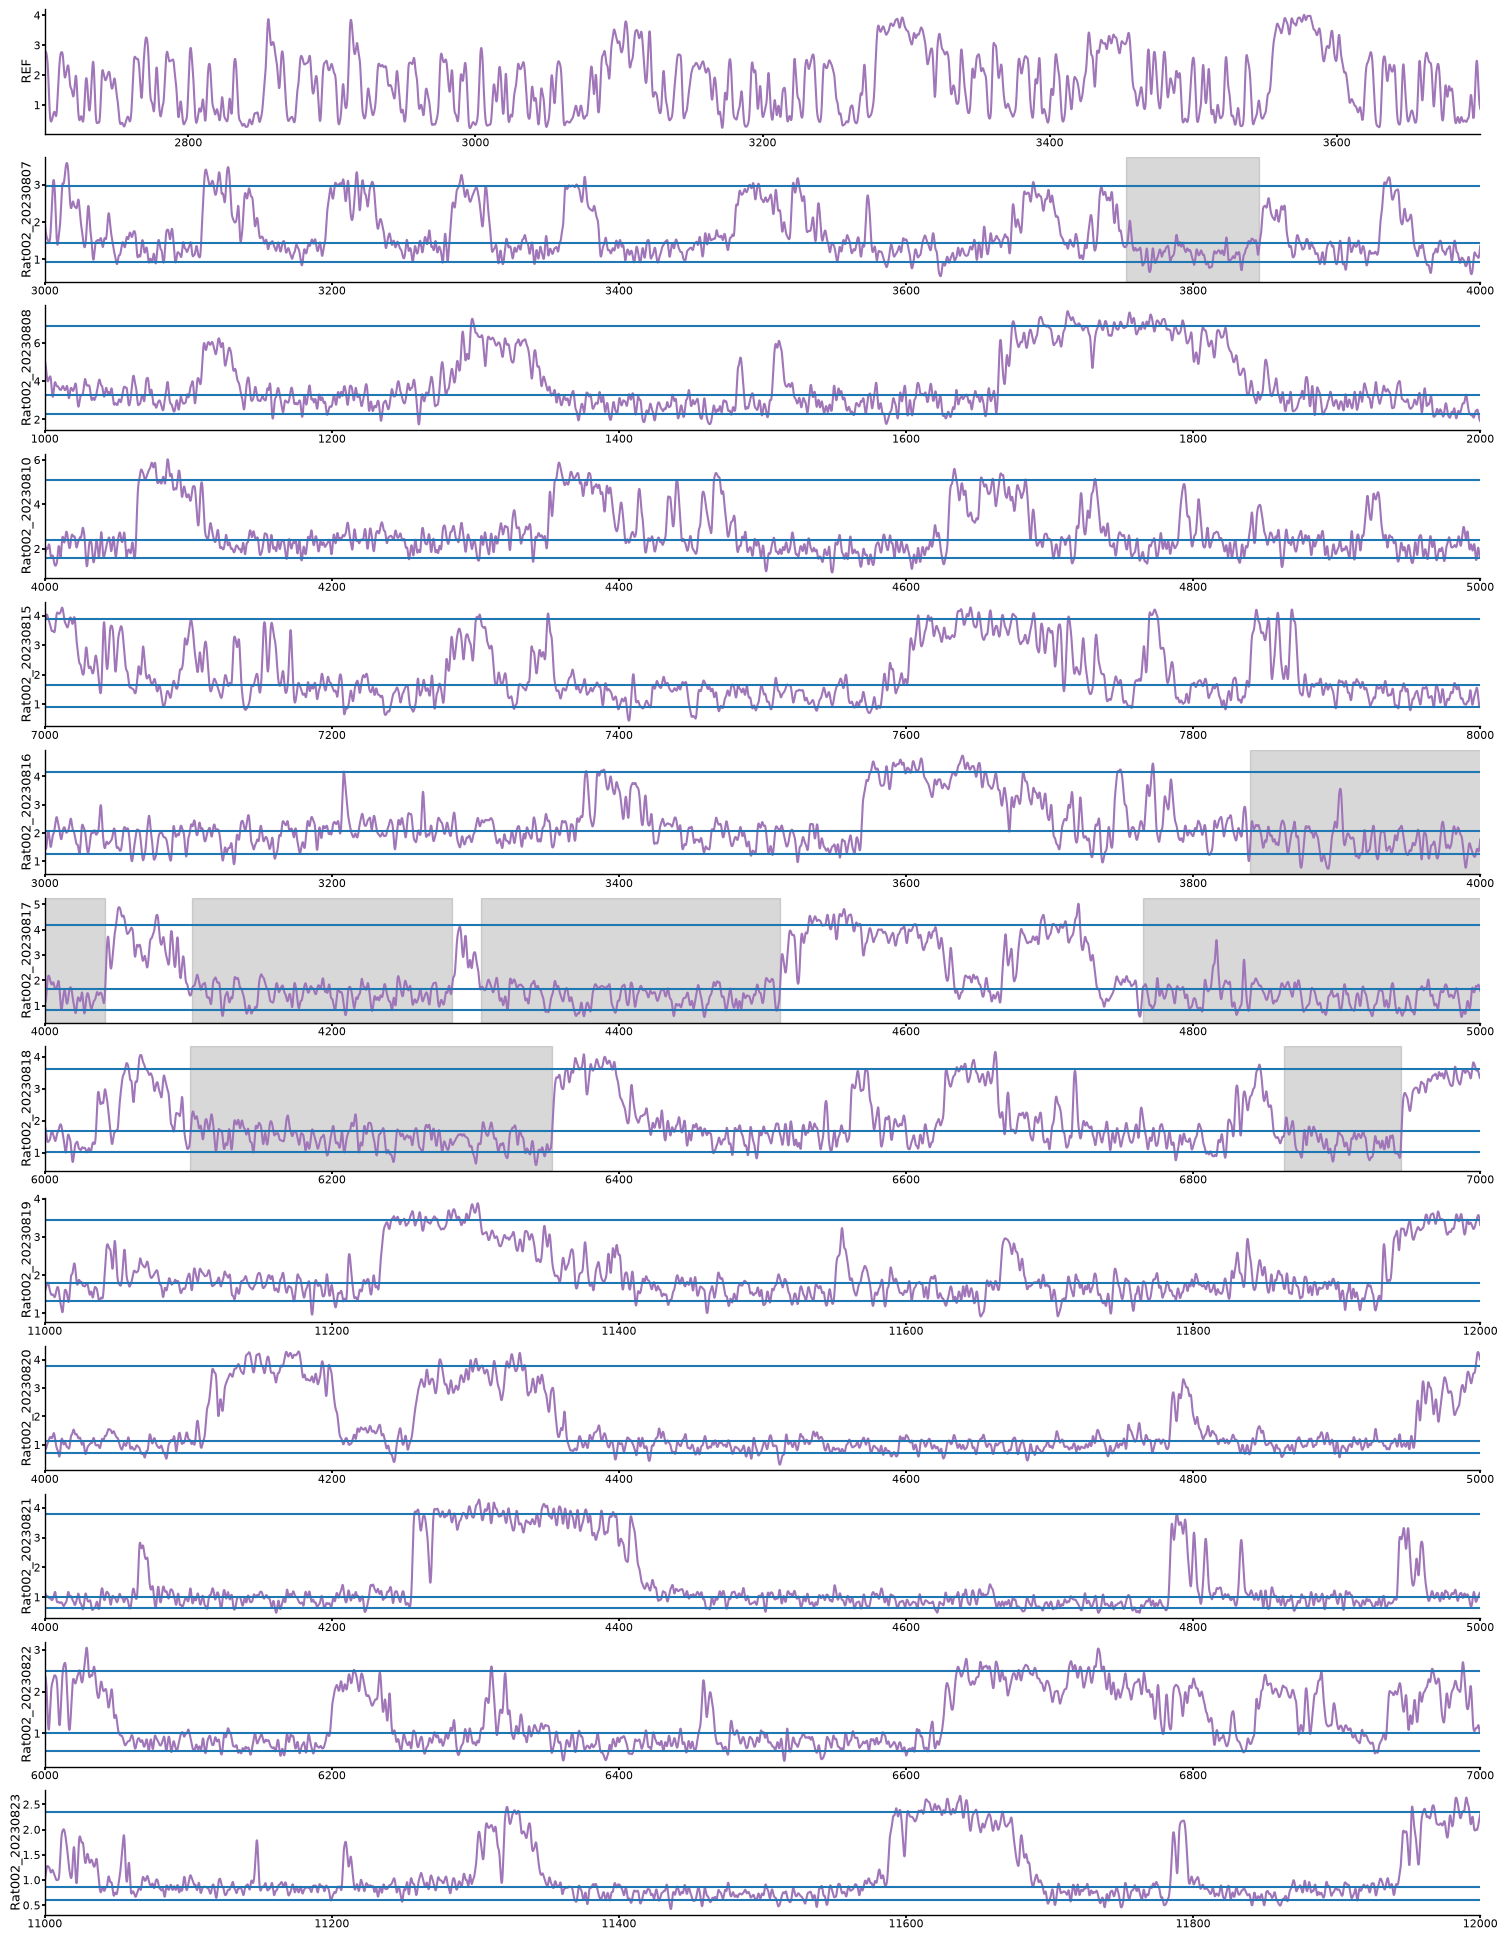

In [22]:
r = 2
sessions = np.where(rat==r)[0]
fig, ax = fma.plotting.makeFigure(n=(len(sessions)+1,1),size=(38,4*len(sessions)+1))

fma.plotting.plotXY(fr[7],window[basename[7]],window[basename[7]]+1000,color=isau.paperColors('nr'),ax=ax[0])
ax[0].set(xlim=[window[basename[7]],window[basename[7]]+1000],ylabel='REF')
print(score(fr[7],window[basename[7]],window[basename[7]]+1000)[0])

scores = []
for i, s in enumerate(sessions):
    start = window[basename[s]]
    stop = start + 1000
    fma.plotting.plotXY(fr[s],start,stop,color=isau.paperColors('nr'),ax=ax[i+1])
    fma.plotting.plotIntervals(isa[s],ax=ax[i+1])
    sc, perc = score(fr[s],start,stop)
    [ax[i+1].axhline(p) for p in perc]
    scores.append(sc)
    ax[i+1].set(xlim=[start,stop],ylabel=basename[s])

test per electrode

In [3]:
def _loadISAElectrode(session):

    has_isa = False
    try:
        R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval')
        has_isa = True
    except FileNotFoundError:
        R = fma.regions.regions(session,events='stimtest')

    fr = R.firingRate(e_groups=R.electrodes(regs='nr'),window=0.05,step=5,smooth=70,norm=True)
    isa = R.eventIntervals('slownr') if has_isa else np.empty((0,2))

    return fr, isa, R.basename, int(R.rat)

In [4]:
fr, isa, basename, rat = fma.data.runBatch(batch_file,_loadISAElectrode,parallel=True)
rat = np.array(rat)


Starting Batch, 2026-09-09 17:02:53.530337 

Error in session /mnt/hubel-data-149/Photon_Rat014/Rat014_2026-07-15_13-31-42/Rat014_2026-07-15_13-31-42.xml (58)
index 0 is out of bounds for axis 0 with size 0
Traceback:
Batch completed with 1 errors, 2026-09-09 17:03:38.574355


0.38204164682747976


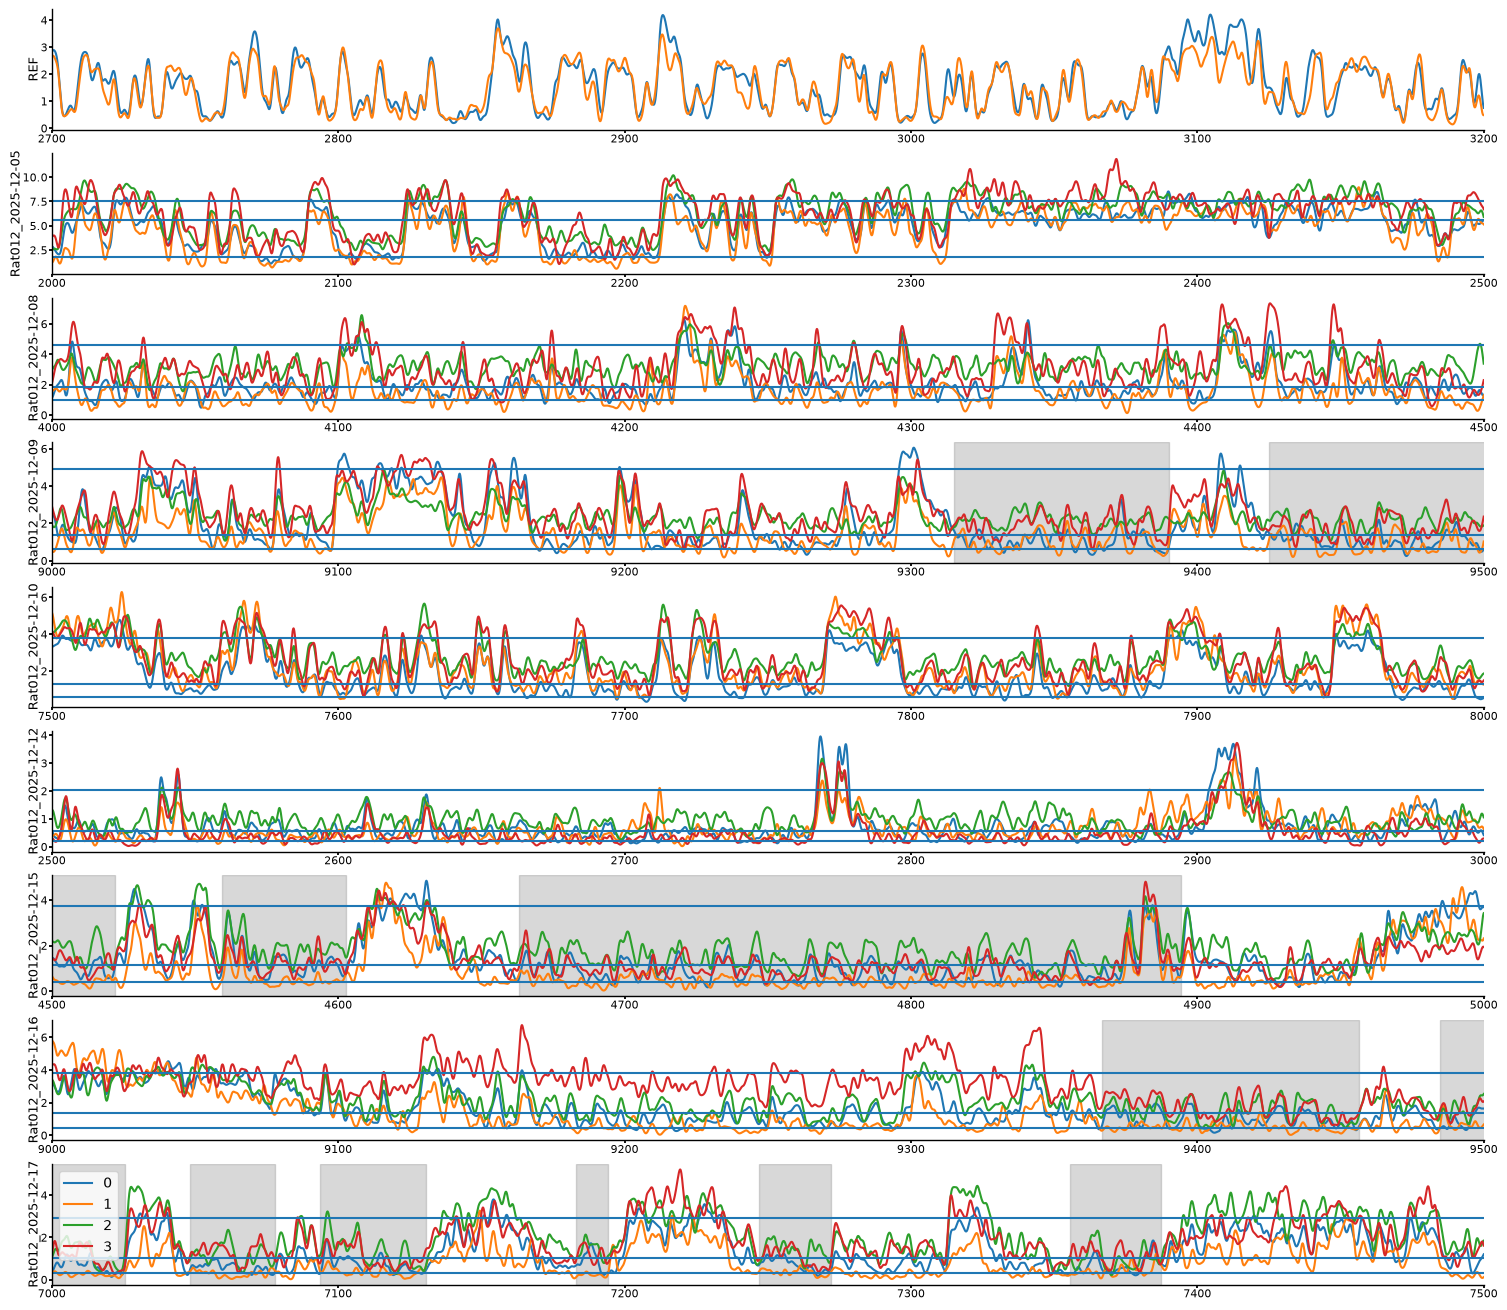

In [17]:
r = 12
sessions = np.where(rat==r)[0]
fig, ax = fma.plotting.makeFigure(n=(len(sessions)+1,1),size=(38,4*len(sessions)+1))

duration = 500
fma.plotting.plotXY(fr[7],window[basename[7]],window[basename[7]]+duration,ax=ax[0]) #,color=isau.paperColors('nr')
ax[0].set(xlim=[window[basename[7]],window[basename[7]]+duration],ylabel='REF')
print(score(fr[7],window[basename[7]],window[basename[7]]+duration)[0])

scores = []
for i, s in enumerate(sessions):
    start = window[basename[s]]
    stop = start + duration
    fma.plotting.plotXY(fr[s],start,stop,label=range(fr[s].shape[1]-1),ax=ax[i+1]) #,color=isau.paperColors('nr')
    fma.plotting.plotIntervals(isa[s],ax=ax[i+1])
    sc, perc = score(fr[s],start,stop)
    [ax[i+1].axhline(p) for p in perc]
    scores.append(sc)
    ax[i+1].set(xlim=[start,stop],ylabel=basename[s])
ax[-1].legend();